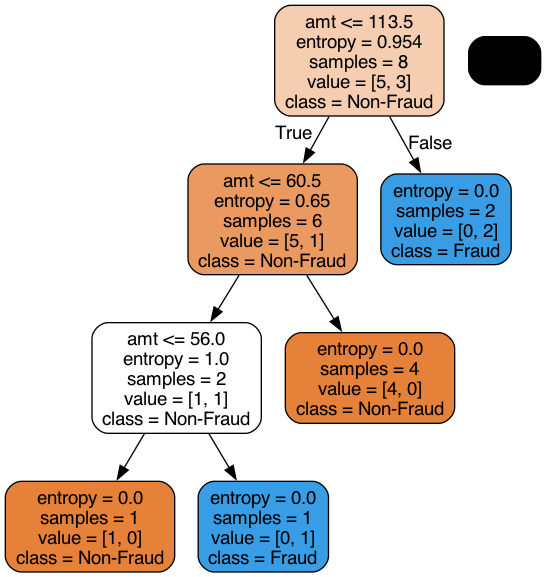

In [9]:
import pandas as pd

from sklearn.tree import DecisionTreeClassifier, export_graphviz
from io import StringIO
import pydotplus
from IPython.display import Image

decision_tree_example = pd.DataFrame({
    "amt": [54, 58, 72, 96, 131, 142, 87, 63],
    "gender": [1, 0, 1, 0, 1, 0, 1, 0],
    "night": [0, 0, 0, 0, 1, 1, 1, 0],
    "is_fraud": [0, 1, 0, 0, 1, 1, 0, 0]
})

X = decision_tree_example.drop(columns=["is_fraud"])
y = decision_tree_example["is_fraud"]

entropy_classifier = DecisionTreeClassifier(
    criterion="entropy",
    random_state=1
)

entropy_classifier.fit(X, y)

def get_entropy_dt_graph(entropy_classifier):

    dot_data = StringIO()

    export_graphviz(
        entropy_classifier,
        out_file=dot_data,
        filled=True,
        rounded=True,
        feature_names=X.columns,
        class_names=["Non-Fraud", "Fraud"]
    )

    entropy_graph = pydotplus.graph_from_dot_data(dot_data.getvalue())

    return entropy_graph

gph_entropy = get_entropy_dt_graph(entropy_classifier)
Image(gph_entropy.create_png())

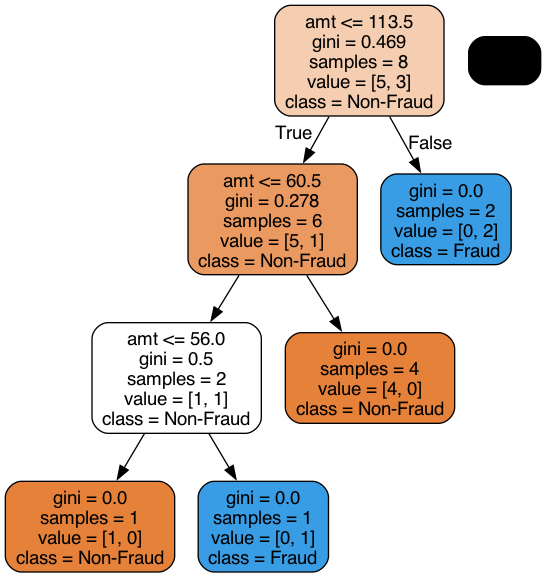

In [10]:
gini_classifier = DecisionTreeClassifier(
    criterion="gini",
    random_state=1
)

gini_classifier.fit(X, y)

def get_gini_dt_graph(gini_classifier):

    dot_data = StringIO()

    export_graphviz(
        gini_classifier,
        out_file=dot_data,
        filled=True,
        rounded=True,
        feature_names=X.columns,
        class_names=["Non-Fraud", "Fraud"]
    )

    gini_graph = pydotplus.graph_from_dot_data(dot_data.getvalue())

    return gini_graph

gph_gini = get_gini_dt_graph(gini_classifier)
Image(gph_gini.create_png())

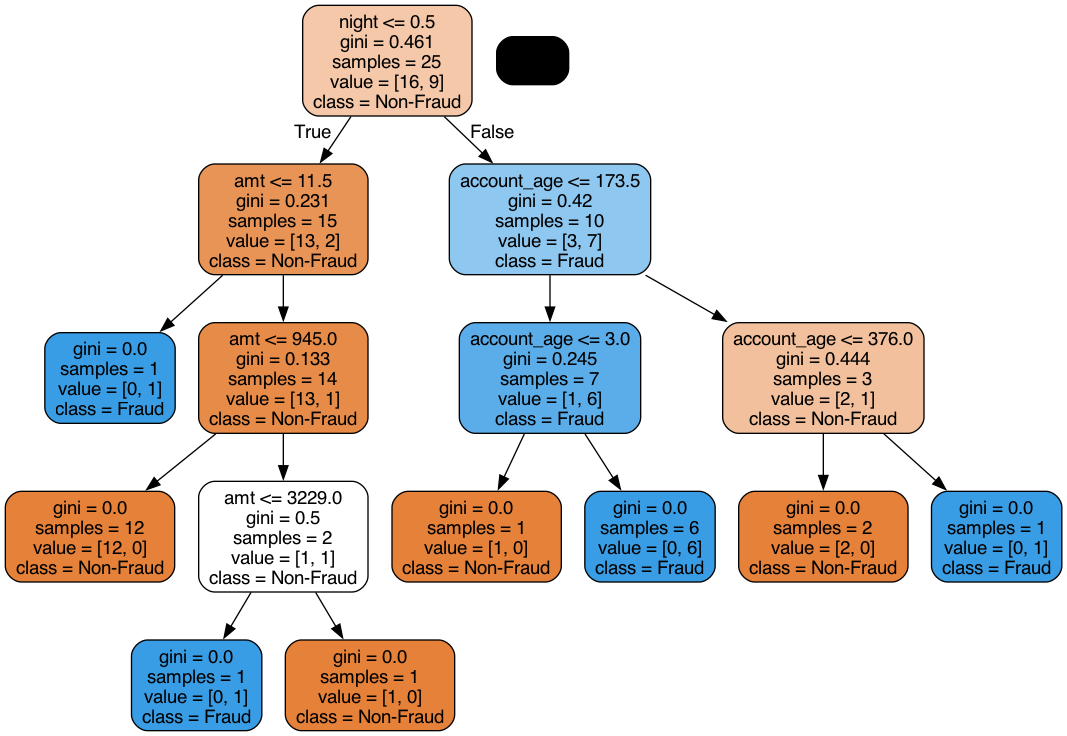

In [14]:

# Example dataset for CCP illustration
decision_tree_example_ccp = pd.DataFrame({
    "amt": [18, 26, 34, 41, 57, 73, 89, 104, 126, 1448,
            173, 5, 238, 2760, 15, 362, 421, 8, 5480,
            10, 702, 835, 912, 978, 1000],
    
    "account_age": [2, 65, 102, 523, 6, 327, 329, 423, 3, 4,
                    5, 16, 108, 137, 144, 210, 263, 315, 237,
                    19, 41, 52, 6, 3, 2],
    
    "night": [0, 0, 0, 0, 1, 0, 1, 1, 0, 1,
              0, 1, 0, 1, 0, 1, 0, 0, 0,
              1, 0, 1, 0, 0, 1],
    
    "is_fraud": [0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
                 0, 1, 0, 1, 0, 0, 0, 1, 0,
                 1, 0, 1, 0, 1, 0]
})

X_ccp = decision_tree_example_ccp.drop(columns=["is_fraud"])
y_ccp = decision_tree_example_ccp["is_fraud"]

# Gini tree
gini_classifier_ccp = DecisionTreeClassifier(
    criterion="gini",
    random_state=1
)

gini_classifier_ccp.fit(X_ccp, y_ccp)

# Visualisation function
def get_gini_dt_graph_ccp(gini_classifier_ccp):

    dot_data = StringIO()

    export_graphviz(
        gini_classifier_ccp,
        out_file=dot_data,
        filled=True,
        rounded=True,
        feature_names=X_ccp.columns,
        class_names=["Non-Fraud", "Fraud"]
    )

    gini_graph_ccp = pydotplus.graph_from_dot_data(dot_data.getvalue())

    return gini_graph_ccp

gph_gini_ccp = get_gini_dt_graph_ccp(gini_classifier_ccp)

Image(gph_gini_ccp.create_png())

In [20]:
path = gini_classifier_ccp.cost_complexity_pruning_path(X_ccp, y_ccp)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.         0.03714286 0.05333333 0.05733333 0.06438095 0.15413333]


In [21]:
gini_classifier_ccp_pruned = DecisionTreeClassifier(
    criterion="gini",
    random_state=1,
    ccp_alpha=ccp_alphas[1]
)

gini_classifier_ccp_pruned.fit(X_ccp, y_ccp)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


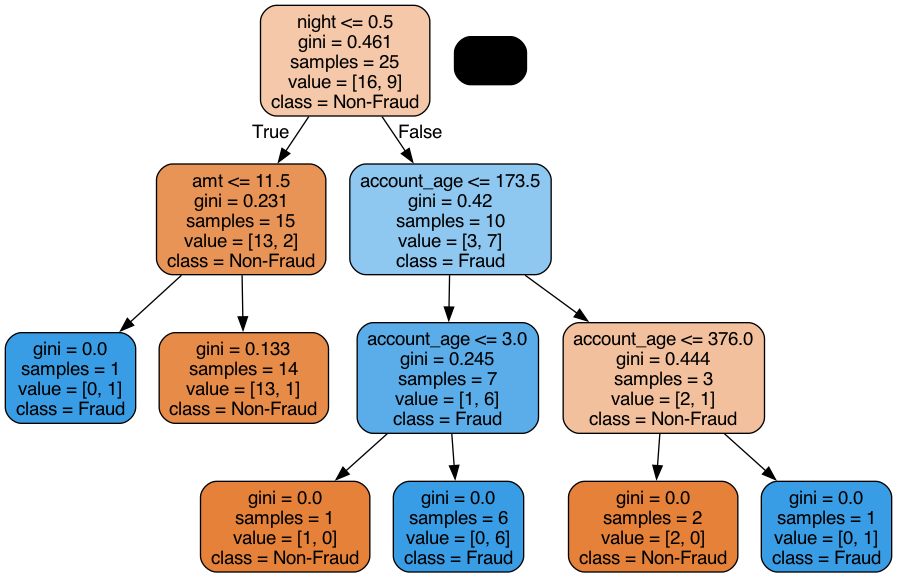

In [22]:
def get_gini_dt_graph_ccp_pruned(gini_classifier_ccp_pruned):

    dot_data = StringIO()

    export_graphviz(
        gini_classifier_ccp_pruned,
        out_file=dot_data,
        filled=True,
        rounded=True,
        feature_names=X_ccp.columns,
        class_names=["Non-Fraud", "Fraud"]
    )

    gini_graph_ccp_pruned = pydotplus.graph_from_dot_data(dot_data.getvalue())

    return gini_graph_ccp_pruned

gph_gini_ccp_pruned = get_gini_dt_graph_ccp_pruned(gini_classifier_ccp_pruned)
Image(gph_gini_ccp_pruned.create_png())

In [120]:
gini_classifier_ccp_less_pruned = DecisionTreeClassifier(

    criterion="gini",

    random_state=1,

    ccp_alpha=0.0645

)

gini_classifier_ccp_less_pruned.fit(X_ccp, y_ccp)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


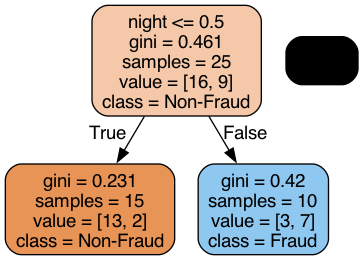

In [121]:
def get_gini_dt_graph_ccp_less_pruned(gini_classifier_ccp_less_pruned):

    dot_data = StringIO()

    export_graphviz(
        gini_classifier_ccp_less_pruned,
        out_file=dot_data,
        filled=True,
        rounded=True,
        feature_names=X_ccp.columns,
        class_names=["Non-Fraud", "Fraud"]
    )

    gini_graph_ccp_less_pruned = pydotplus.graph_from_dot_data(
        dot_data.getvalue()
    )

    return gini_graph_ccp_less_pruned

gph_gini_ccp_less_pruned = get_gini_dt_graph_ccp_less_pruned(
    gini_classifier_ccp_less_pruned
)

Image(gph_gini_ccp_less_pruned.create_png())

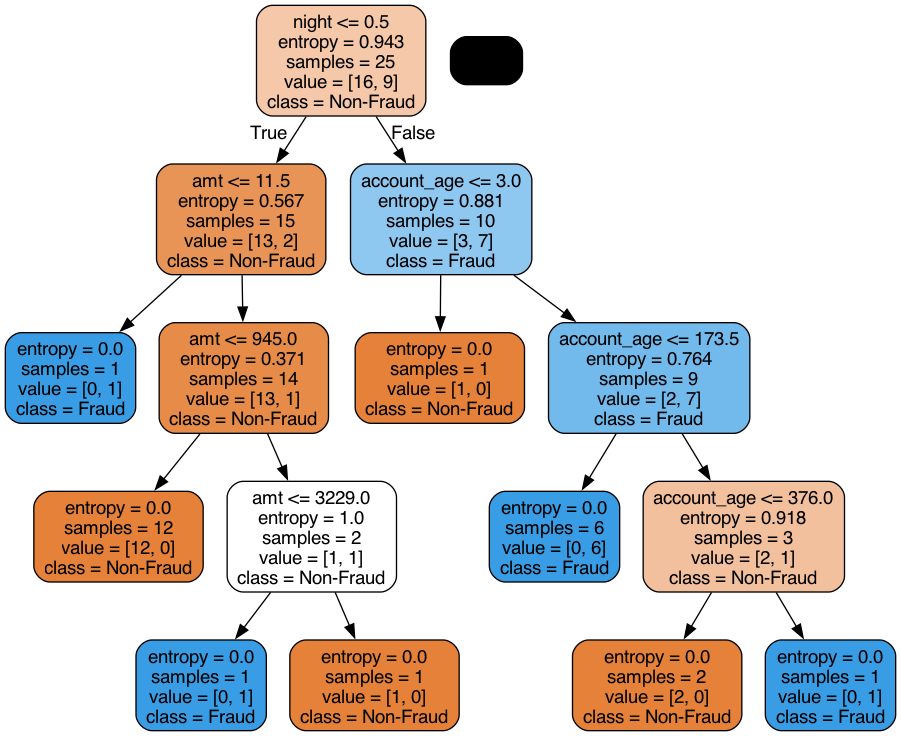

In [15]:
# Example dataset for CCP illustration
decision_tree_example_ccp = pd.DataFrame({
    "amt": [18, 26, 34, 41, 57, 73, 89, 104, 126, 1448,
            173, 5, 238, 2760, 15, 362, 421, 8, 5480,
            10, 702, 835, 912, 978, 1000],
    
    "account_age": [2, 65, 102, 523, 6, 327, 329, 423, 3, 4,
                    5, 16, 108, 137, 144, 210, 263, 315, 237,
                    19, 41, 52, 6, 3, 2],
    
    "night": [0, 0, 0, 0, 1, 0, 1, 1, 0, 1,
              0, 1, 0, 1, 0, 1, 0, 0, 0,
              1, 0, 1, 0, 0, 1],
    
    "is_fraud": [0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
                 0, 1, 0, 1, 0, 0, 0, 1, 0,
                 1, 0, 1, 0, 1, 0]
})

X_ccp = decision_tree_example_ccp.drop(columns=["is_fraud"])
y_ccp = decision_tree_example_ccp["is_fraud"]

# Entropy tree
entropy_classifier_ccp = DecisionTreeClassifier(
    criterion="entropy",
    random_state=1
)

entropy_classifier_ccp.fit(X_ccp, y_ccp)

# Visualisation function
def get_entropy_dt_graph_ccp(entropy_classifier_ccp):

    dot_data = StringIO()

    export_graphviz(
        entropy_classifier_ccp,
        out_file=dot_data,
        filled=True,
        rounded=True,
        feature_names=X_ccp.columns,
        class_names=["Non-Fraud", "Fraud"]
    )

    entropy_graph_ccp = pydotplus.graph_from_dot_data(dot_data.getvalue())

    return entropy_graph_ccp

gph_entropy_ccp = get_entropy_dt_graph_ccp(entropy_classifier_ccp)

Image(gph_entropy_ccp.create_png())